# LOD MLP Training
**COMP 432 — Adaptive LOD Control**

Pipeline:
1. Load `training_data_labeled.csv`
2. Select and normalize features
3. Split train/validation
4. Define MLP (64 -> 32 -> 16 -> 1, Sigmoid output)
5. Train with MSE loss + Adam
6. Evaluate and plot
7. Export to ONNX for Unity Sentis

In [1]:
import sys
!{sys.executable} -m pip install torch torchvision pandas scikit-learn matplotlib joblib onnx

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib
import os



print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


## 1. Configuration

In [3]:
# CONFIG
INPUT_FILE   = '../data/Train_Merged_labeled/training_data_labeled.csv'
MODEL_OUT    = '../models/lod_mlp.onnx'
SCALER_OUT   = '../models/feature_scaler.pkl'

FEATURE_COLS = [
    'cam_rot_y',              # 0.55 — never used before
    'screen_coverage',        # 0.54
    'visible_renderer_count', # 0.51
    'cam_pos_y',              # 0.49 — never used before
    'triangle_count',         # 0.49
    'path_progress',          # 0.48 — never used before
    'draw_call_estimate',     # 0.48
    'camera_velocity',        # 0.37
    'gpu_frame_time_ms',      # 0.36
    'cam_pos_x',              # 0.34 — never used before
    'cam_pos_z',              # 0.30 — never used before
    'fps',                    # 0.21
]

TARGET_COL   = 'target_lod_bias'

# MLP architecture (from project docs)
HIDDEN1 = 64
HIDDEN2 = 32
HIDDEN3 = 16

# Training
BATCH_SIZE        = 512
EPOCHS            = 150
LR                = 1e-3
VAL_SPLIT         = 0.2
SEED              = 42
DIVERSITY_WEIGHT  = 0.01  # penalizes mean collapse in predictions

# LOD bias range for output denormalization
BIAS_MIN = 0.25
BIAS_MAX = 2.0
#

torch.manual_seed(SEED)
np.random.seed(SEED)


## 2. Load and Inspect Data

In [7]:
# Load the local processed dataset
df = pd.read_csv(INPUT_FILE)
print(f'Loaded {len(df)} rows, {len(df.columns)} columns')

# Show Target Bias distribution
print(f'\nTarget distribution (LOD Bias):')
print(df[TARGET_COL].value_counts().sort_index())

# Show initial Feature statistics
print(f'\nFeature summary stats:')
display(df[FEATURE_COLS].describe().round(3))


Loaded 240000 rows, 27 columns

Target distribution (LOD Bias):
target_lod_bias
0.263860     188
0.288202     611
0.289320     640
0.299152     121
0.310399     579
            ... 
1.760604    1007
1.782237     258
1.871805      97
1.878720      79
2.000000     418
Name: count, Length: 232, dtype: int64

Feature summary stats:


,cam_rot_y,screen_coverage,visible_renderer_count,cam_pos_y,triangle_count,path_progress,draw_call_estimate,camera_velocity,gpu_frame_time_ms,cam_pos_x,cam_pos_z,fps
count,240000.000,240000.000,240000.000,240000.000,240000.000,240000.000,240000.000,240000.000,240000.000,240000.000,240000.000,240000.000
mean,98.532,0.012,7716.229,3.928,316152.931,3.200,2302.292,1.748,4.877,13.810,7.813,97.054
std,88.632,0.011,6414.349,2.476,223689.448,2.144,1707.306,1.250,1.522,19.927,24.006,66.625
min,0.030,0.000,0.000,1.310,4325.000,1.000,11.000,0.000,1.885,-65.190,-58.350,6.820
25%,32.890,0.002,3068.750,2.040,157611.750,1.631,990.000,0.500,3.935,-0.320,-4.160,59.990
50%,49.875,0.009,5124.000,2.740,239993.000,2.218,1771.000,0.503,4.593,24.480,14.000,73.275
75%,108.430,0.021,10701.000,6.000,389682.000,4.559,2928.000,3.000,5.468,28.180,28.410,109.860
max,359.980,0.039,32309.000,8.560,2501593.000,11.454,17753.000,3.012,20.862,52.990,67.910,531.970


## 3. Preprocessing

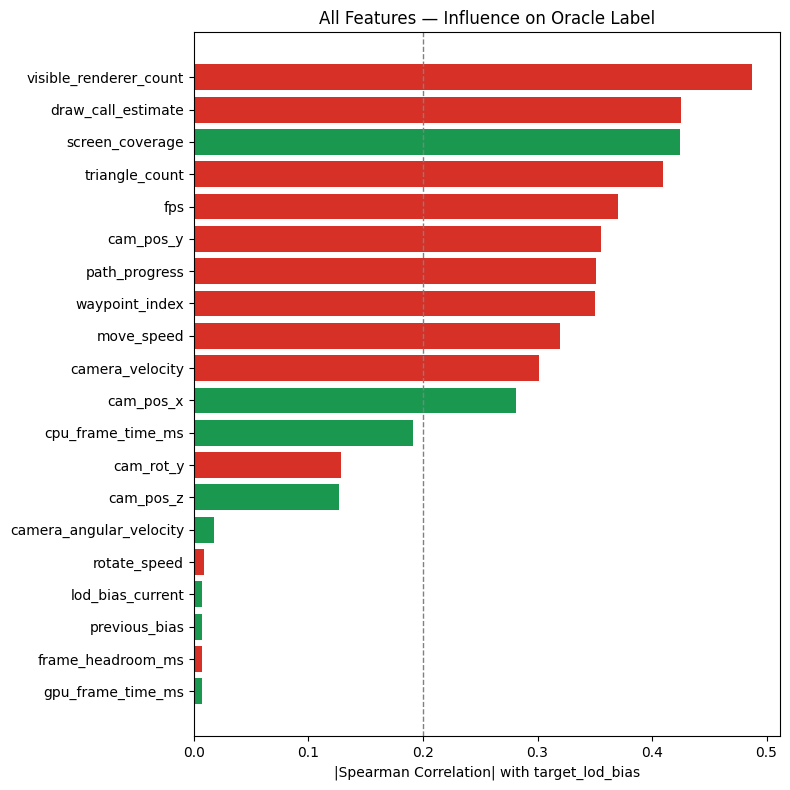

  visible_renderer_count         -0.4874  (- bias)
  draw_call_estimate             -0.4253  (- bias)
  screen_coverage                +0.4243  (+ bias)
  triangle_count                 -0.4092  (- bias)
  fps                            -0.3702  (- bias)
  cam_pos_y                      -0.3551  (- bias)
  path_progress                  -0.3511  (- bias)
  waypoint_index                 -0.3505  (- bias)
  move_speed                     -0.3199  (- bias)
  camera_velocity                -0.3009  (- bias)
  cam_pos_x                      +0.2812  (+ bias)
  cpu_frame_time_ms              +0.1916  (+ bias)
  cam_rot_y                      -0.1285  (- bias)
  cam_pos_z                      +0.1270  (+ bias)
  camera_angular_velocity        +0.0178  (+ bias)
  rotate_speed                   -0.0086  (- bias)
  previous_bias                  +0.0073  (+ bias)
  lod_bias_current               +0.0073  (+ bias)
  gpu_frame_time_ms              +0.0066  (+ bias)
  frame_headroom_ms            

In [ ]:
FEATURE_COLS = [
    'cpu_frame_time_ms', 'gpu_frame_time_ms', 'triangle_count',
    'camera_velocity', 'camera_angular_velocity', 'visible_renderer_count',
    'draw_call_estimate', 'frame_headroom_ms', 'screen_coverage',
    'lod_bias_current', 'fps', 'previous_bias',
    'cam_pos_x', 'cam_pos_y', 'cam_pos_z', 'cam_rot_y',
    'path_progress', 'waypoint_index', 'move_speed', 'rotate_speed'
]

corr = df[ALL_FEATURES + [TARGET_COL]].corr(method='spearman')[TARGET_COL].drop(TARGET_COL)
corr_sorted = corr.abs().sort_values(ascending=True)
colors = ['#d73027' if corr[f] < 0 else '#1a9850' for f in corr_sorted.index]

plt.figure(figsize=(8, 8))
plt.barh(corr_sorted.index, corr_sorted.values, color=colors)
plt.axvline(x=0.2, color='gray', linestyle='--', linewidth=1)
plt.xlabel('|Spearman Correlation| with target_lod_bias')
plt.title('All Features — Influence on Oracle Label')
plt.tight_layout()
plt.savefig('../plots/training/feature_influence_all.png', dpi=150)
plt.show()

for f in corr.abs().sort_values(ascending=False).index:
    direction = "+ bias" if corr[f] > 0 else "- bias"
    print(f"  {f:<30} {corr[f]:+.4f}  ({direction})")

In [10]:
# Drop rows with NaN in features or target
df = df.dropna(subset=FEATURE_COLS + [TARGET_COL])
print(f'Rows after dropna: {len(df)}')

X     = df[FEATURE_COLS].values.astype(np.float32)
y_raw = df[TARGET_COL].values.astype(np.float32)

#  Label diagnostic
print(f'\nRaw target_lod_bias stats:')
print(f'  min={y_raw.min():.4f}  max={y_raw.max():.4f}  mean={y_raw.mean():.4f}  std={y_raw.std():.4f}')
print(f'  unique values: {len(np.unique(y_raw.round(4)))}')

# Normalize target to [0, 1] for Sigmoid output
y = (y_raw - BIAS_MIN) / (BIAS_MAX - BIAS_MIN)
print(f'\nNormalized target range: [{y.min():.4f}, {y.max():.4f}]')
print(f'Normalized target std:   {y.std():.4f}  (< 0.05 = collapse risk)')

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)
joblib.dump(scaler, SCALER_OUT)
assert os.path.exists(SCALER_OUT), f'Scaler not saved: {SCALER_OUT}'
print(f'Scaler saved to {SCALER_OUT}')

#  Feature variance diagnostic
print(f'\nFeature std after scaling (should all be ~1.0):')
for name, std in zip(FEATURE_COLS, X.std(axis=0)):
    flag = '  <-- LOW VARIANCE' if std < 0.5 else ''
    print(f'  {name:<30} std={std:.4f}{flag}')

# Split off 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)
# Split remaining into 80% train / 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, shuffle=True
)

print(f'\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')


Rows after dropna: 240000

Raw target_lod_bias stats:
  min=0.2639  max=2.0000  mean=1.2858  std=0.3724
  unique values: 230

Normalized target range: [0.0079, 1.0000]
Normalized target std:   0.2128  (< 0.05 = collapse risk)
Scaler saved to ../models/feature_scaler.pkl

Feature std after scaling (should all be ~1.0):
  cpu_frame_time_ms              std=1.0000
  gpu_frame_time_ms              std=1.0000
  triangle_count                 std=1.0000
  camera_velocity                std=1.0000
  camera_angular_velocity        std=1.0000
  visible_renderer_count         std=1.0000
  draw_call_estimate             std=1.0000
  frame_headroom_ms              std=1.0000
  screen_coverage                std=1.0000
  lod_bias_current               std=1.0000
  fps                            std=1.0000
  previous_bias                  std=1.0000
  cam_pos_x                      std=1.0000
  cam_pos_y                      std=1.0000
  cam_pos_z                      std=1.0000
  cam_rot_y         

## 4. Dataset and DataLoader

In [11]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t,   y_val_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 300 | Val batches: 75


## 5. Model Definition
Architecture from project docs: Input -> 64 (ReLU) -> 32 (ReLU) -> 1 (Sigmoid)

In [12]:
class LODPredictor(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, hidden3=16):
        super(LODPredictor, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, hidden3),
            nn.ReLU(),
            nn.Linear(hidden3, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

INPUT_DIM = X_train.shape[1]
model     = LODPredictor(INPUT_DIM, HIDDEN1, HIDDEN2, HIDDEN3).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params}')

LODPredictor(
  (layers): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Total parameters: 3969


## 6. Training

In [13]:
def diversity_loss(preds, weight=DIVERSITY_WEIGHT):
    """Penalize low batch prediction variance — prevents mean collapse."""
    pred_std = preds.std()
    if pred_std < 1e-6:
        return torch.tensor(0.0, device=preds.device)
    return -weight * pred_std

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.HuberLoss(delta=0.3)

BEST_MODEL_PATH = '../models/best_model.pt'

train_losses     = []
train_div_losses = []
val_losses       = []
best_val_loss    = float('inf')

for epoch in range(EPOCHS):
    # --- train ---
    model.train()
    batch_losses = []
    div_losses   = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        preds = model(X_batch)

        huber = criterion(preds, y_batch)
        div   = diversity_loss(preds)
        loss  = huber + div

        loss.backward()
        optimizer.step()
        batch_losses.append(huber.item())
        div_losses.append(abs(div.item()))

    train_loss = np.mean(batch_losses)
    train_div  = np.mean(div_losses)

    #  validate (no diversity term)
    model.eval()
    with torch.no_grad():
        val_batch_losses = []
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = model(X_batch)
            val_batch_losses.append(criterion(preds, y_batch).item())
        val_loss = np.mean(val_batch_losses)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)

    train_losses.append(train_loss)
    train_div_losses.append(train_div)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Huber: {train_loss:.6f} | Div: {train_div:.6f} | Val: {val_loss:.6f}')

print('Training complete.')

# Reload best checkpoint
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
print(f'Loaded best model (val loss: {best_val_loss:.6f})')

# --- test ---
with torch.no_grad():
    X_test_t   = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    y_test_t   = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(DEVICE)
    test_preds = model(X_test_t)
    test_loss  = criterion(test_preds, y_test_t).item()

test_preds_bias  = test_preds.detach().cpu().numpy().flatten() * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_target_bias = y_test * (BIAS_MAX - BIAS_MIN) + BIAS_MIN

test_mae  = np.mean(np.abs(test_preds_bias - test_target_bias))
test_rmse = np.sqrt(np.mean((test_preds_bias - test_target_bias) ** 2))

print(f'\nTest Huber (normalized): {test_loss:.6f}')
print(f'Test MAE   (bias units): {test_mae:.4f}')
print(f'Test RMSE  (bias units): {test_rmse:.4f}')
print(f'\nPredicted bias — min: {test_preds_bias.min():.4f}  max: {test_preds_bias.max():.4f}  std: {test_preds_bias.std():.4f}')
print(f'Oracle  bias  — min: {test_target_bias.min():.4f}  max: {test_target_bias.max():.4f}  std: {test_target_bias.std():.4f}')

KeyboardInterrupt: 

## 7. Loss Curves

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses,   label='Val MSE')
plt.axhline(y=test_loss, color='red', linestyle='--', label=f'Test MSE = {test_loss:.6f}')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Training, Validation and Test Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../plots/training/loss_curve.png', dpi=150)
plt.show()

print(f'Final Train MSE : {train_losses[-1]:.6f}')
print(f'Final Val   MSE : {val_losses[-1]:.6f}')
print(f'Test        MSE : {test_loss:.6f}')
print(f'Test        MAE : {test_mae:.4f} (bias units)')
print(f'Test        RMSE: {test_rmse:.4f} (bias units)')

## 8. Evaluation — Denormalized Predictions



Val  MAE: 0.1685 | Val  RMSE: 0.2503
Test MAE: 0.1707 | Test RMSE: 0.2536


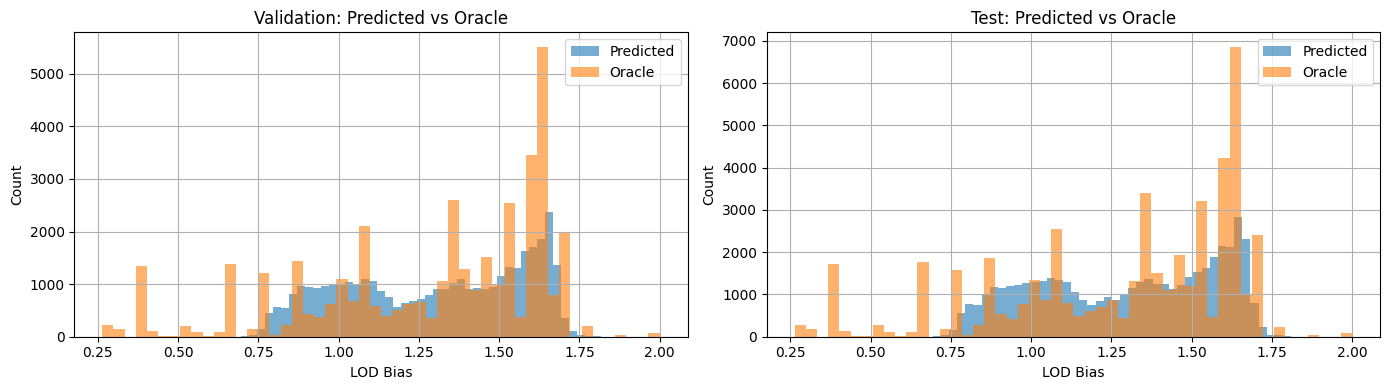

In [ ]:
model.eval()
with torch.no_grad():
    preds_norm      = model(X_val_t.to(DEVICE)).cpu().numpy().flatten()
    test_preds_norm = model(torch.tensor(X_test, dtype=torch.float32).to(DEVICE)).cpu().numpy().flatten()

# Denormalize
preds_bias       = preds_norm      * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_preds_bias  = test_preds_norm * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
target_bias      = y_val           * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_target_bias = y_test          * (BIAS_MAX - BIAS_MIN) + BIAS_MIN

# Metrics
val_mae  = np.mean(np.abs(preds_bias  - target_bias))
val_rmse = np.sqrt(np.mean((preds_bias  - target_bias) ** 2))
t_mae    = np.mean(np.abs(test_preds_bias - test_target_bias))
t_rmse   = np.sqrt(np.mean((test_preds_bias - test_target_bias) ** 2))

print(f'Val  MAE: {val_mae:.4f} | Val  RMSE: {val_rmse:.4f}')
print(f'Test MAE: {t_mae:.4f} | Test RMSE: {t_rmse:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(preds_bias,  bins=50, alpha=0.6, label='Predicted')
axes[0].hist(target_bias, bins=50, alpha=0.6, label='Oracle')
axes[0].set_title('Validation: Predicted vs Oracle')
axes[0].set_xlabel('LOD Bias')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True)

axes[1].hist(test_preds_bias,  bins=50, alpha=0.6, label='Predicted')
axes[1].hist(test_target_bias, bins=50, alpha=0.6, label='Oracle')
axes[1].set_title('Test: Predicted vs Oracle')
axes[1].set_xlabel('LOD Bias')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../plots/training/prediction_distribution.png', dpi=150)
plt.show()


checks which input features the trained model depends on. It shuffles one feature at a time and runs inference again. If the model’s loss increases, that feature is important; if not, it has little impact.

Baseline test loss: 0.009990

Permutation Importance (loss increase when feature is shuffled):
  visible_renderer_count         +0.006088
  fps                            +0.004376
  cam_pos_z                      +0.002422
  gpu_frame_time_ms              +0.001927
  screen_coverage                +0.001861
  cam_pos_x                      +0.001487
  draw_call_estimate             +0.001295
  cam_rot_y                      +0.001209
  frame_headroom_ms              +0.001166
  cam_pos_y                      +0.000788
  triangle_count                 +0.000744
  cpu_frame_time_ms              +0.000661
  path_progress                  +0.000633
  camera_velocity                +0.000569
  camera_angular_velocity        +0.000468
  lod_bias_current               +0.000387
  waypoint_index                 +0.000370
  move_speed                     +0.000360
  previous_bias                  +0.000304
  rotate_speed                   +0.000164


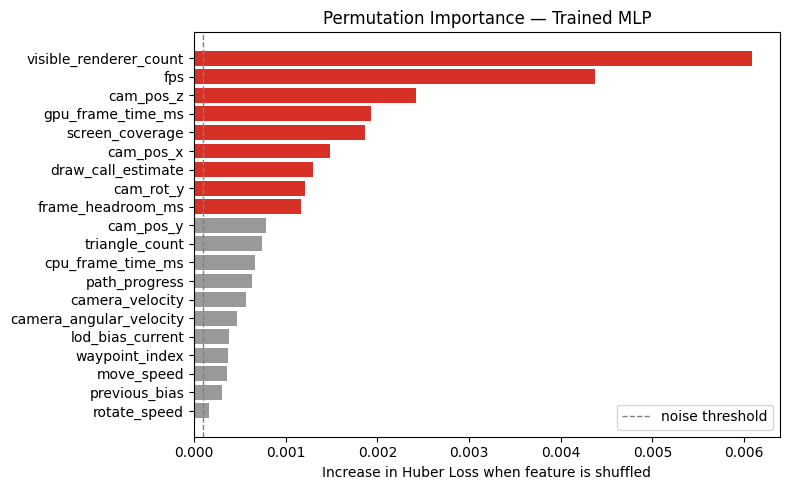

In [ ]:
# Permutation Importance   which features actually matter to the trained model
import numpy as np
import matplotlib.pyplot as plt

model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(DEVICE)

with torch.no_grad():
    baseline_loss = criterion(model(X_test_t), y_test_t).item()

importance = {}
for i, name in enumerate(FEATURE_COLS):
    X_perm = X_test.copy()
    np.random.shuffle(X_perm[:, i])        # shuffle one column, leave rest intact
    X_perm_t = torch.tensor(X_perm, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        perm_loss = criterion(model(X_perm_t), y_test_t).item()
    importance[name] = perm_loss - baseline_loss  # higher = more important

importance_sorted = dict(sorted(importance.items(), key=lambda x: x[1]))

print(f"Baseline test loss: {baseline_loss:.6f}")
print(f"\nPermutation Importance (loss increase when feature is shuffled):")
for name, delta in sorted(importance.items(), key=lambda x: x[1], reverse=True):
    flag = "  <-- USELESS" if delta < 0.0001 else ""
    print(f"  {name:<30} +{delta:.6f}{flag}")

# Plot
colors = ['#d73027' if v > 0.001 else '#999999' for v in importance_sorted.values()]
plt.figure(figsize=(8, 5))
plt.barh(list(importance_sorted.keys()), list(importance_sorted.values()), color=colors)
plt.axvline(x=0.0001, color='gray', linestyle='--', linewidth=1, label='noise threshold')
plt.xlabel('Increase in Huber Loss when feature is shuffled')
plt.title('Permutation Importance — Trained MLP')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/training/permutation_importance.png', dpi=150)
plt.show()

## 9. Export to ONNX for Unity Sentis

In [19]:
#!pip install onnxscript onnx
%pip install torch torchvision pandas scikit-learn matplotlib joblib onnx
%pip install onnxscript


Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/689.1 kB ? eta -:--:--
   ---------------------------------------- 689.1/689.1 kB 9.1 MB/s  0:00:00

   ---------------------------------------- 0/2 [onnx_ir]
   ---------------------------------------- 0/2 [onnx_ir]
   ---------------------------------------- 0/2 [onnx_ir]
   ---------------------------------------- 0/2 [onnx_ir]
   ---------------------------------------- 0/2 [onnx_ir]
   ---------------------------------------- 0/2 [onnx_ir]
   ---------------------------------------- 0/2 [onnx_ir]
   ---------------------------------------- 0/2 [onnx_ir]
   -------------------- ------------------- 1/2 [onnxscript]
   -------------------- ------------------- 1/2 [onnxscript]
   -------------------- ------------------- 1/2 [onnxscript]
   -------------------- ------------------- 1/2 [onnxscript]
   -------------------- ------------------- 1/2 [onnxscript]
   -------------

In [20]:
model.eval()
model.cpu()

dummy_input = torch.zeros(1, INPUT_DIM, dtype=torch.float32)

torch.onnx.export(
    model,
    dummy_input,
    MODEL_OUT,
    export_params=True,
    opset_version=15,
    input_names=['features'],
    output_names=['lod_bias_normalized'],
    dynamic_axes={
        'features':           {0: 'batch_size'},
        'lod_bias_normalized': {0: 'batch_size'}
    }
)

size_kb = os.path.getsize(MODEL_OUT) / 1024
print(f'ONNX model saved to {MODEL_OUT} ({size_kb:.1f} KB)')
print(f'Input dim: {INPUT_DIM} features')
print(f'Output: normalized bias in [0,1] -> denormalize with BIAS_MIN={BIAS_MIN}, BIAS_MAX={BIAS_MAX}')

C:\Users\Gica\AppData\Local\Temp\ipykernel_36300\438338614.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0322 22:37:02.352000 36300 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 15 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `LODPredictor([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `LODPredictor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


C:\Users\Gica\AppData\Roaming\uv\python\cpython-3.12.13-windows-x86_64-none\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 15).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX model saved to ../models/lod_mlp.onnx (2.2 KB)
Input dim: 20 features
Output: normalized bias in [0,1] -> denormalize with BIAS_MIN=0.25, BIAS_MAX=2.0


In [21]:
import onnx

# Load the split model (needs both .onnx and .onnx.data in same folder)
model_onnx = onnx.load(MODEL_OUT, load_external_data=True)

# Save as single self-contained file - no external data
SINGLE_OUT = '../models/lod_mlp_single.onnx'
onnx.save_model(
    model_onnx,
    SINGLE_OUT,
    save_as_external_data=False
)

import os
size_kb = os.path.getsize(SINGLE_OUT) / 1024
print(f'Saved single-file ONNX: {SINGLE_OUT} ({size_kb:.1f} KB)')

Saved single-file ONNX: ../models/lod_mlp_single.onnx (17.0 KB)


### 9b. Export Scaler Constants to JSON

In [22]:
import json, joblib

scaler = joblib.load(SCALER_OUT)

constants = {
    'mean':          scaler.mean_.tolist(),
    'scale':         scaler.scale_.tolist(),
    'feature_names': FEATURE_COLS,
    'bias_min':      BIAS_MIN,
    'bias_max':      BIAS_MAX
}

SCALER_JSON = '../models/scaler_constants.json'
with open(SCALER_JSON, 'w') as f:
    json.dump(constants, f, indent=2)

print(f'Saved to {SCALER_JSON}')
print(json.dumps(constants, indent=2))

Saved to ../models/scaler_constants.json
{
  "mean": [
    16.88257946464916,
    4.876507954761386,
    316152.9307916667,
    1.748204849352191,
    3.506286335172504,
    7716.229258333334,
    2302.291675,
    11.723495739044935,
    0.011943262101327127,
    1.0833333333333333,
    97.05378871168494,
    1.0833333333333333,
    13.80990333375195,
    3.92800682673653,
    7.812829208941439,
    98.532380665165,
    3.2001974619428317,
    2.75025,
    1.75,
    1.0
  ],
  "scale": [
    11.851831391061458,
    1.5219428656269964,
    223688.98225391746,
    1.2504734163094429,
    14.173278920449672,
    6414.3353661810215,
    1707.3028909391055,
    1.5219437359261434,
    0.01107962914451361,
    0.7168604389202189,
    66.62529025191249,
    0.7168604389202189,
    19.926688961539256,
    2.476384429800599,
    24.006366975579972,
    88.6314050027458,
    2.1443483451467062,
    2.1434357009639142,
    1.25,
    0.5
  ],
  "feature_names": [
    "cpu_frame_time_ms",
    "gpu_

## 10. Unity Sentis Integration Notes

In `NeuralLODController.cs`, denormalize the output:

```csharp
float normalizedBias = output[0];  // Sigmoid output in [0,1]
float targetBias = normalizedBias * (2.0f - 0.25f) + 0.25f;// BIAS_MIN = 0.25f, BIAS_MAX = 2.0f
```

Feature order for the input tensor must match `FEATURE_COLS` exactly:
```
0  cpu_frame_time_ms
1  gpu_frame_time_ms
2  triangle_count
3  camera_velocity
4  camera_angular_velocity
5  visible_renderer_count
6  draw_call_estimate
7  frame_headroom_ms
8  screen_coverage
9  lod_bias_current
```

Apply scaler mean/std from `feature_scaler.pkl` to each feature before inference:
```csharp
float[] scalerMean = { /* from scaler.mean_ */ };
float[] scalerStd  = { /* from scaler.scale_ */ };
for (int i = 0; i < features.Length; i++)
    features[i] = (features[i] - scalerMean[i]) / scalerStd[i];
```